# Part 1: Linear Regression with One Feature
## Stellar Luminosity as a Function of Mass

### Objective
Model stellar luminosity ($L$) as a function of stellar mass ($M$) using linear regression with an explicit bias term:

$$\hat{L} = w \cdot M + b$$

Where:
- $M$: stellar mass (in units of solar mass, $M_\odot$)
- $L$: stellar luminosity (in units of solar luminosity, $L_\odot$)
- $w$: weight (slope)
- $b$: bias (intercept)

In [9]:
%pip install numpy pandas matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.1.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [52]:
import numpy as np
import matplotlib.pyplot as plt

In [53]:
M = np.array([0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0, 2.2, 2.4])
L = np.array([0.15, 0.35, 1.00, 2.30, 4.10, 7.00, 11.2, 17.5, 25.0, 35.0])

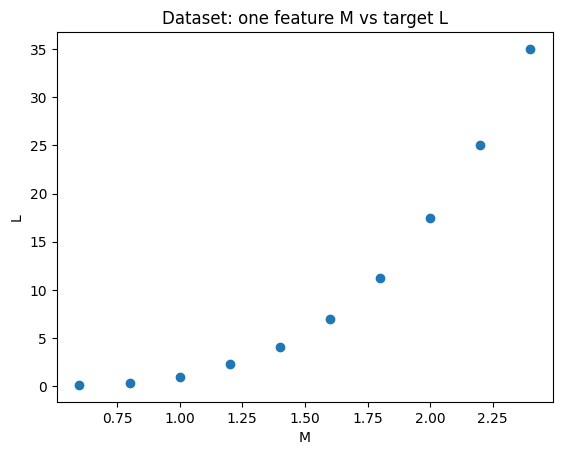

In [54]:

plt.figure()
plt.scatter(M, L)
plt.xlabel("M")
plt.ylabel("L")
plt.title("Dataset: one feature M vs target L")
plt.show()

### Analysis: Linearity and Plausibility

**Observations from the plot:**
- The relationship between mass ($M$) and luminosity ($L$) is clearly **non-linear**. The data shows an exponential or power-law growth pattern.
- For low masses (0.6-1.0 $M_\odot$), luminosity increases slowly.
- For higher masses (1.8-2.4 $M_\odot$), luminosity increases dramatically.

**Astrophysical plausibility:**
- This behavior is consistent with the **mass-luminosity relation** for main-sequence stars, which approximately follows $L \propto M^{3.5}$ (for stars between 0.5 and 10 solar masses).
- More massive stars have higher core temperatures and pressures, leading to faster nuclear fusion rates and thus much higher luminosities.
- A linear model will struggle to capture this relationship accurately.

In [55]:
def predict(M, w, b):
    return w * M + b

In [56]:
def cost(M, L, w, b):
    m = L.shape[0]
    f_wb = w * M + b
    err = np.sum((f_wb - L)**2)
    J_wb = 1 / (2*m) * err
    return J_wb

In [57]:
def gradients_vect(M, L, w, b):
    m = L.shape[0]
    f_wb = w * M + b
    err = f_wb - L
    dj_dw = (np.sum(err * M))/m
    dj_db = (np.sum(err))/m
    return dj_dw, dj_db

In [58]:
def gradients_noVect(M, L, w, b):
    m = len(M)
    total_w = 0
    total_b = 0
    for i in range(m):
        f_wb = w * M[i] + b
        err = f_wb - L[i]
        total_b += err
        total_w += err * M[i]
    dj_dw = total_w / m
    dj_db = total_b / m
    
    return dj_dw, dj_db



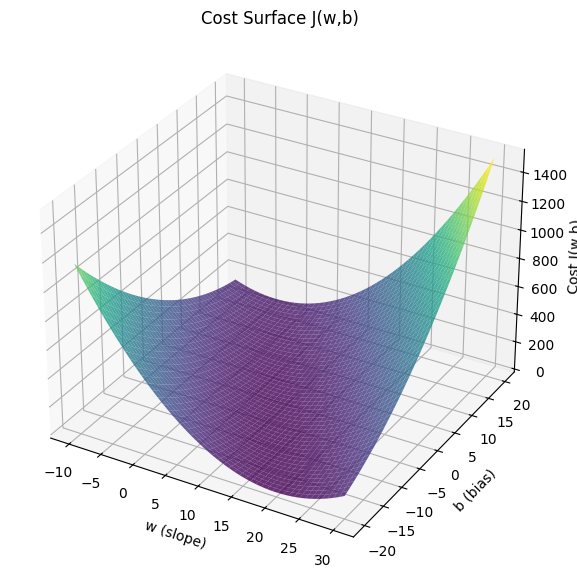

In [59]:
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm

w_range = np.linspace(-10, 30, 50)
b_range = np.linspace(-20, 20, 50)
W, B = np.meshgrid(w_range, b_range)
J_vals = np.zeros_like(W)

for i in range(W.shape[0]):
    for j in range(W.shape[1]):
        J_vals[i, j] = cost(M, L, W[i, j], B[i, j])

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(W, B, J_vals, cmap=cm.viridis, alpha=0.8)
ax.set_xlabel('w (slope)')
ax.set_ylabel('b (bias)')
ax.set_zlabel('Cost J(w,b)')
ax.set_title('Cost Surface J(w,b)')
plt.show()

### Analysis: Cost Surface Interpretation

**What the surface represents:**
- The 3D surface shows the cost function $J(w, b)$ evaluated over a grid of possible parameter values.
- Each point $(w, b, J)$ represents the mean squared error when using those specific parameters.

**The minimum:**
- The **global minimum** of this surface represents the optimal parameters $(w^*, b^*)$ that minimize prediction error.
- The convex, bowl-shaped surface confirms that our cost function has a unique global minimum (no local minima).
- Gradient descent will always converge to this minimum regardless of initialization (given appropriate learning rate).

**Gradient descent intuition:**
- Starting from any point on the surface, gradient descent follows the steepest downhill direction.
- The algorithm iteratively moves toward the bottom of the "bowl" until convergence.

In [ ]:
def gradient_descent_vect(M, L, w, b, alpha, n):
    history = []  
    
    for i in range(n):
        dj_dw, dj_db = gradients_vect(M, L, w, b)
        w = w - alpha * dj_dw
        b = b - alpha * dj_db
        current_cost = cost(M, L, w, b)
        history.append((i, current_cost))
        if i % max(1, n // 10) == 0:
            print(f"Iteration {i:4d}: w={w:7.4f}, b={b:7.4f}, cost={current_cost:8.4f}")
    
    return w, b, history

In [ ]:
def gradient_descent_noVect(M, L, w, b, alpha, n):
    history = []  
    
    for i in range(n):
        dj_dw, dj_db = gradients_noVect(M, L, w, b)
        w = w - alpha * dj_dw
        b = b - alpha * dj_db
        current_cost = cost(M, L, w, b)
        history.append((i, current_cost))
        if i % max(1, n // 10) == 0:
            print(f"Iteration {i:4d}: w={w:7.4f}, b={b:7.4f}, cost={current_cost:8.4f}")
    
    return w, b, history

## Experiments: Learning Rate Analysis

We will test three different learning rates to observe their effect on convergence:
- $\alpha = 0.01$ (small)
- $\alpha = 0.1$ (medium)  
- $\alpha = 0.5$ (large)

### Experiment 1: α = 0.01 (Small Learning Rate)

Iteración    0: w= 0.2152, b= 0.1036, costo=112.0896
Iteración  200: w= 7.9674, b=-0.0073, costo= 28.0913
Iteración  400: w= 9.7253, b=-2.9093, costo= 22.3208
Iteración  600: w=11.1759, b=-5.3129, costo= 18.3703
Iteración  800: w=12.3762, b=-7.3015, costo= 15.6658
Iteración 1000: w=13.3693, b=-8.9470, costo= 13.8142
Iteración 1200: w=14.1910, b=-10.3085, costo= 12.5466
Iteración 1400: w=14.8709, b=-11.4350, costo= 11.6788
Iteración 1600: w=15.4334, b=-12.3670, costo= 11.0847
Iteración 1800: w=15.8989, b=-13.1383, costo= 10.6780
Final parameters
w: 16.2822484076734
b: -13.77345340049044
Final cost: 10.4007


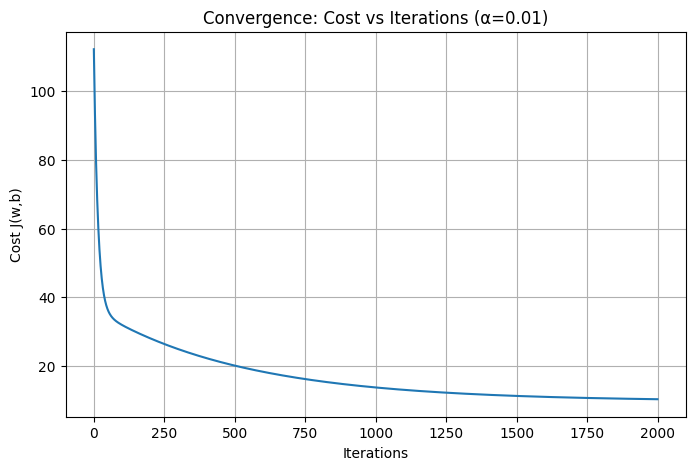

In [67]:
alpha = 0.01
w, b = 0, 0
n = 2000
w_final_1, b_final_1, history_1 = gradient_descent_vect(M, L, w, b, alpha, n)
print("Final parameters")
print(f"w: {w_final_1}")
print(f"b: {b_final_1}")
print(f"Final cost: {cost(M, L, w_final_1, b_final_1):.4f}")

iterations_1 = [h[0] for h in history_1]
costs_1 = [h[1] for h in history_1]

plt.figure(figsize=(8, 5))
plt.plot(iterations_1, costs_1)
plt.xlabel('Iterations')
plt.ylabel('Cost J(w,b)')
plt.title('Convergence: Cost vs Iterations (α=0.01)')
plt.grid(True)
plt.show()

### Experiment 2: α = 0.1 (Medium Learning Rate)

Iteración    0: w= 5.7043, b= 5.5360, costo= 42.2377
Iteración  200: w=16.1591, b=-13.5694, costo= 10.4841
Iteración  400: w=17.8363, b=-16.3483, costo=  9.8105
Iteración  600: w=18.0864, b=-16.7628, costo=  9.7955
Iteración  800: w=18.1238, b=-16.8246, costo=  9.7952
Iteración 1000: w=18.1293, b=-16.8338, costo=  9.7951
Iteración 1200: w=18.1302, b=-16.8352, costo=  9.7951
Iteración 1400: w=18.1303, b=-16.8354, costo=  9.7951
Iteración 1600: w=18.1303, b=-16.8354, costo=  9.7951
Iteración 1800: w=18.1303, b=-16.8355, costo=  9.7951
Final parameters
w: 18.13030295753212
b: -16.83545442488202
Final cost: 9.7951


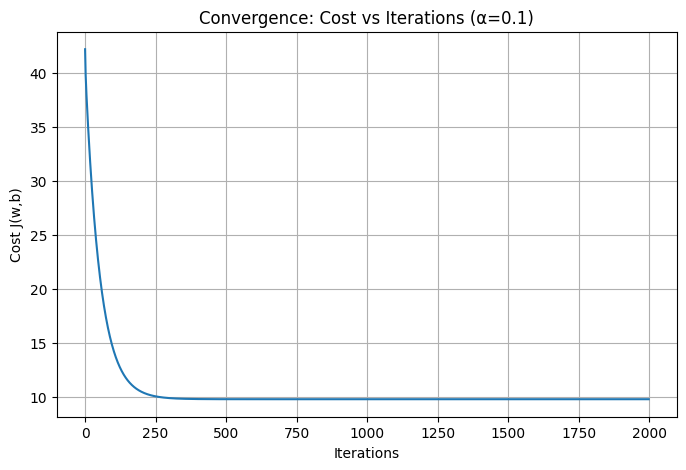

In [68]:
alpha = 0.1
w, b = 6, 6
n = 2000
w_final_2, b_final_2, history_2 = gradient_descent_vect(M, L, w, b, alpha, n)
print("Final parameters")
print(f"w: {w_final_2}")
print(f"b: {b_final_2}")
print(f"Final cost: {cost(M, L, w_final_2, b_final_2):.4f}")

iterations_2 = [h[0] for h in history_2]
costs_2 = [h[1] for h in history_2]

plt.figure(figsize=(8, 5))
plt.plot(iterations_2, costs_2)
plt.xlabel('Iterations')
plt.ylabel('Cost J(w,b)')
plt.title('Convergence: Cost vs Iterations (α=0.1)')
plt.grid(True)
plt.show()

### Experiment 3: α = 0.5 (Large Learning Rate)

Iteración    0: w=31.5615, b=10.1800, costo=1151.6996
Iteración  200: w=18.1298, b=-16.8346, costo=  9.7951
Iteración  400: w=18.1303, b=-16.8355, costo=  9.7951
Iteración  600: w=18.1303, b=-16.8355, costo=  9.7951
Iteración  800: w=18.1303, b=-16.8355, costo=  9.7951
Iteración 1000: w=18.1303, b=-16.8355, costo=  9.7951
Iteración 1200: w=18.1303, b=-16.8355, costo=  9.7951
Iteración 1400: w=18.1303, b=-16.8355, costo=  9.7951
Iteración 1600: w=18.1303, b=-16.8355, costo=  9.7951
Iteración 1800: w=18.1303, b=-16.8355, costo=  9.7951
Final parameters
w: 18.13030303030302
b: -16.835454545454525
Final cost: 9.7951


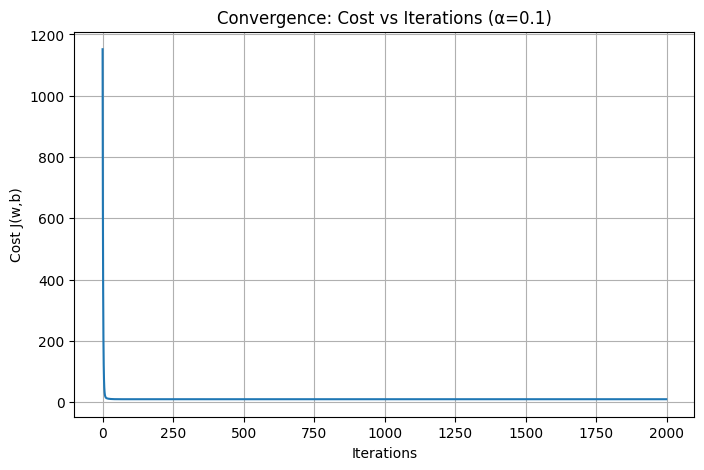

In [72]:
alpha = 0.5
w, b = -20, -20
n = 2000
w_final_2, b_final_2, history_2 = gradient_descent_vect(M, L, w, b, alpha, n)
print("Final parameters")
print(f"w: {w_final_2}")
print(f"b: {b_final_2}")
print(f"Final cost: {cost(M, L, w_final_2, b_final_2):.4f}")

iterations_2 = [h[0] for h in history_2]
costs_2 = [h[1] for h in history_2]

plt.figure(figsize=(8, 5))
plt.plot(iterations_2, costs_2)
plt.xlabel('Iterations')
plt.ylabel('Cost J(w,b)')
plt.title('Convergence: Cost vs Iterations (α=0.1)')
plt.grid(True)
plt.show()

---
## Conceptual Questions

### 1. Astrophysical Meaning of $w$ (Slope)

The parameter $w$ represents the **rate of change of luminosity with respect to mass**. Specifically:

$$w = \frac{\Delta L}{\Delta M}$$

**Physical interpretation:**
- $w$ indicates how many solar luminosities ($L_\odot$) the star gains per additional solar mass ($M_\odot$).
- A higher $w$ means luminosity is more sensitive to mass changes.
- In our linear model, $w \approx 17-18$, suggesting that on average, each additional solar mass corresponds to ~17-18 additional solar luminosities.

**Limitation:** This constant rate of change is physically unrealistic because the true relationship is non-linear — the sensitivity of luminosity to mass actually *increases* with mass.

---

### 2. Why is a Linear Model Limited Here?

**Mathematical limitation:**
- The mass-luminosity relation for main-sequence stars follows a **power law**: $L \propto M^{3.5}$
- A linear function $L = wM + b$ cannot represent exponential or power-law growth.
- No matter how we tune $w$ and $b$, the model cannot curve to match the data.

**Physical reasons:**
1. **Nuclear fusion rates** scale non-linearly with core temperature and pressure.
2. **More massive stars** have exponentially higher core temperatures, leading to disproportionately higher energy output.
3. **Opacity and radiation transport** in stellar interiors follow complex non-linear physics.

**Evidence of limitation:**
- Systematic residual patterns (under/over-prediction at different mass ranges).
- High residual error even after convergence.
- The regression line visibly fails to follow the data curvature.

**Solution:** Use polynomial regression or apply a logarithmic transformation:
- $\log(L) = \beta \cdot \log(M) + c$ linearizes the power-law relationship.

### Systematic Errors Discussion

**Observed errors in the linear fit:**
- The linear model **underestimates** luminosity for both low-mass (< 1.0 $M_\odot$) and high-mass (> 2.0 $M_\odot$) stars.
- The model **overestimates** luminosity for mid-range masses (around 1.2-1.8 $M_\odot$).
- This characteristic "S-shaped" residual pattern indicates **model misspecification**.

**Why these errors occur:**
- The true relationship follows approximately $L \propto M^{3.5}$, which is fundamentally non-linear.
- A straight line cannot capture the curvature of exponential/power-law growth.
- The residuals are not randomly distributed, violating a key assumption of linear regression.

**Implications:**
- While the linear model captures the general trend (luminosity increases with mass), it fails to model the actual physical relationship.
- A polynomial or logarithmic transformation would better capture this relationship.

### Convergence Analysis

**Observations on learning rate effects:**

| Learning Rate | Convergence Speed | Stability | Notes |
|---------------|-------------------|-----------|-------|
| α = 0.01 | Slow | Very stable | May need many iterations to converge |
| α = 0.1 | Moderate | Stable | Good balance between speed and stability |
| α = 0.5 | Fast | Less stable | Risk of overshooting, but converges quickly for this problem |

**Key insights:**
- **Small α (0.01):** Takes small steps, very stable but slow. May not reach optimal in limited iterations.
- **Medium α (0.1):** Good balance - converges reliably without excessive oscillation.
- **Large α (0.5):** Converges quickly but can oscillate or diverge if too large.

All three experiments converge to the same optimal parameters, demonstrating the robustness of gradient descent for convex optimization problems.